# Perturbation Performance vs. Number of Perturbed Genes

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '../../scripts')

import numpy as np
import pandas as pd
import decoupler as dc
import matplotlib.pyplot as plt
import scanpy as sc
import scvi
from scipy.stats import pearsonr, spearmanr

import cellina
from cellina import CellinaModel, make_neighbor_perturbation
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features
from perturb_utils import load_crc_slide
from configs.cellina_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
from counterfactual_analysis import (
    safe_log2_fold_change, precision_at_k,
    e_distance, subsample_cells, _normalize_counts,
)

plt.rcParams['figure.dpi'] = 100
scvi.settings.seed = 0
print(cellina.__version__)


EDISTANCE_SUBSAMPLE = 500
EDISTANCE_N_ITER = 10


def direction_match(gt_vec, cf_vec, k):
    gt_topk = set(np.argsort(-np.abs(gt_vec))[:k])
    cf_topk = set(np.argsort(-np.abs(cf_vec))[:k])
    intersect = list(gt_topk & cf_topk)
    if len(intersect) == 0:
        return 0.0
    return float(np.mean(np.sign(gt_vec[intersect]) == np.sign(cf_vec[intersect])))


def compute_metrics(ref_expr, pert_expr, obs_expr, top_n=200, eps=1e-8, scale=1e4):
    """Mirrors eval_loo compute_lfc_metrics + get_edistance on raw expression arrays."""
    ref_norm  = _normalize_counts(ref_expr,  eps=eps, scale=scale)
    obs_norm  = _normalize_counts(obs_expr,  eps=eps, scale=scale)
    pert_norm = _normalize_counts(pert_expr, eps=eps, scale=scale)

    mean_ref  = np.nanmean(ref_norm,  axis=0)
    mean_obs  = np.nanmean(obs_norm,  axis=0)
    mean_pert = np.nanmean(pert_norm, axis=0)

    gt_vec = safe_log2_fold_change(mean_obs,  mean_ref, eps=eps)
    cf_vec = safe_log2_fold_change(mean_pert, mean_ref, eps=eps)

    top_features = np.argsort(-np.abs(gt_vec))[:top_n]
    pear,  _ = pearsonr( gt_vec[top_features], cf_vec[top_features])
    spear, _ = spearmanr(gt_vec[top_features], cf_vec[top_features])
    prec     = precision_at_k(gt_vec, cf_vec, k=top_n, use_abs=True)
    dir_m    = direction_match(gt_vec, cf_vec, k=top_n)

    pop_a = np.log1p(obs_norm[:,  top_features])
    pop_b = np.log1p(pert_norm[:, top_features])
    edists = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE))
        for _ in range(EDISTANCE_N_ITER)
    ]
    edists_local = [
        e_distance(subsample_cells(pop_a, EDISTANCE_SUBSAMPLE),
                   subsample_cells(pop_b, EDISTANCE_SUBSAMPLE), local=True)
        for _ in range(EDISTANCE_N_ITER)
    ]
    rmse_log1p = float(np.sqrt(np.mean(
        (np.log1p(obs_norm).sum(0) - np.log1p(pert_norm).sum(0)) ** 2
    )))

    return dict(
        pearson_r=float(pear),
        spearman_r=float(spear),
        precision=float(prec),
        direction_match=float(dir_m),
        edistance=float(np.mean(edists)),
        edistance_local=float(np.mean(edists_local)),
        rmse_log1p=rmse_log1p,
    )


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

0.7.1


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id             = 242
labels_key           = 'coarse_type'
domains_key          = 'typ'
top_n                = 100                        # metric evaluation window (fixed)
top_n_perturb_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 3000] # sweep
batch_size           = 512
min_cells            = 50
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_ID'
library_size     = 'latent'

ref_label = f'{slide_id}_REF'
crc_label = f'{slide_id}_CRC'

## 1. Data

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

  0%|          | 0.00/1.03G [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)

## 2. Model

In [ ]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_obsm_key='spatial_x'
)

model = CellinaModel(adata, **MODEL_ARGS)


In [ ]:
train_args = {**TRAIN_ARGS, "devices": [1], "batch_size": batch_size, "train_size": 0.9, "validation_size": 0.1}
model.train(**train_args, plan_kwargs=PLAN_KWARGS)

model.save(save_path, overwrite=True)


## 3. Pseudobulk logFC — Global & Cell-type-specific

In [ ]:
model = CellinaModel.load(save_path, adata)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
2026-03-31 21:00:46 | [INFO] Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File results/perturb_loo/trained/crc_242_ID/model.pt already downloaded                                   


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.l

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


In [ ]:
# Global: all cells pooled together
pdata_global = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=None, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_global, target_sum=1e4)
sc.pp.log1p(pdata_global)

global_logfc_series = pd.Series(
    (pdata_global[pdata_global.obs[domains_key] == crc_label].X
     - pdata_global[pdata_global.obs[domains_key] == ref_label].X).flatten(),
    index=pdata_global.var_names,
)

# Cell-type-specific
pdata_ct = dc.pp.pseudobulk(
    adata=adata, sample_col=domains_key, groups_col=labels_key, mode='sum', layer='counts'
)
sc.pp.normalize_total(pdata_ct, target_sum=1e4)
sc.pp.log1p(pdata_ct)

cell_types_with_both = [
    ct for ct in pdata_ct.obs[labels_key].unique()
    if ((pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)).any()
    and ((pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)).any()
]

domain_logfc_df = pd.concat(
    [
        pd.Series(
            (pdata_ct[(pdata_ct.obs[domains_key] == crc_label) & (pdata_ct.obs[labels_key] == ct)].X
             - pdata_ct[(pdata_ct.obs[domains_key] == ref_label) & (pdata_ct.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata_ct.var_names,
            name=ct,
        )
        for ct in cell_types_with_both
    ],
    axis=1,
).T

print(f"Global logFC: {global_logfc_series.shape[0]} genes")
print(f"CT-specific logFC: {domain_logfc_df.shape} (cell types × genes)")

Global logFC: 3000 genes
CT-specific logFC: (8, 3000) (cell types × genes)


## 4. Pre-compute Fixed Expressions per Cell Type

In [ ]:
import scanpy as sc  # needed for sc.pp calls above in case not imported

ref_idxs = {}   # ct → indices in REF
crc_idxs = {}   # ct → indices in CRC
ref_exprs = {}  # ct → (n_ref, n_genes)
cf_exprs  = {}  # ct → (n_crc, n_genes)  real CRC, ground truth
swap_exprs = {} # ct → (n_ref, n_genes)  counterfactual (graph swap)

cell_types = []
for ct in sorted(cell_types_with_both):
    ref_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
    )[0]
    crc_idx = np.where(
        (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == crc_label)
    )[0]
    if len(ref_idx) < min_cells or len(crc_idx) < min_cells:
        print(f"  skip {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
        continue
    print(f"  {ct}: ref={len(ref_idx)}, crc={len(crc_idx)}")
    ref_idxs[ct]  = ref_idx
    crc_idxs[ct]  = crc_idx
    ref_exprs[ct]  = model.get_normalized_expression(indices=ref_idx, batch_size=batch_size, library_size=library_size)
    cf_exprs[ct]   = model.get_normalized_expression(indices=crc_idx, batch_size=batch_size, library_size=library_size)
    swap_exprs[ct] = model.get_counterfactual_expression(ref_idx, crc_idx, batch_size=batch_size, library_size=library_size)
    cell_types.append(ct)

print(f"\nEvaluating {len(cell_types)} cell types: {cell_types}")

  Endothelial: ref=982, crc=1642
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Epithelial: ref=19472, crc=53313


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


  Fibroblast: ref=6100, crc=22548
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  Mast_cell: ref=795, crc=383


...

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
  T_cell: ref=4580, crc=3245


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        

Evaluating 8 cell types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


## 5. Counterfactual Baseline (Fixed)

In [ ]:
_metric_keys = ('pearson_r', 'spearman_r', 'precision', 'direction_match', 'edistance', 'edistance_local', 'rmse_log1p')
cf_metrics_vals = {k: [] for k in _metric_keys}
for ct in cell_types:
    stats = compute_metrics(ref_exprs[ct], swap_exprs[ct], cf_exprs[ct], top_n=top_n)
    for k in _metric_keys:
        cf_metrics_vals[k].append(stats[k])

cf_avg_pearson    = float(np.mean(cf_metrics_vals['pearson_r']))
cf_avg_spearman   = float(np.mean(cf_metrics_vals['spearman_r']))
cf_avg_prec       = float(np.mean(cf_metrics_vals['precision']))
cf_avg_dir_match  = float(np.mean(cf_metrics_vals['direction_match']))
cf_avg_edistance  = float(np.mean(cf_metrics_vals['edistance']))
cf_avg_edist_loc  = float(np.mean(cf_metrics_vals['edistance_local']))
cf_avg_rmse_log1p = float(np.mean(cf_metrics_vals['rmse_log1p']))
print(f"Counterfactual avg Pearson r       = {cf_avg_pearson:.3f}")
print(f"Counterfactual avg Spearman r      = {cf_avg_spearman:.3f}")
print(f"Counterfactual avg precision@{top_n:<4} = {cf_avg_prec:.3f}")
print(f"Counterfactual avg direction_match = {cf_avg_dir_match:.3f}")
print(f"Counterfactual avg edistance       = {cf_avg_edistance:.4f}")
print(f"Counterfactual avg edist_local     = {cf_avg_edist_loc:.4f}")
print(f"Counterfactual avg RMSE log1p      = {cf_avg_rmse_log1p:.4f}")


## 6. Sweep: Global vs Cell-type-specific

In [ ]:
global_results        = []
ctspec_results        = []
global_edist_results  = []
ctspec_edist_results  = []
global_spear_results  = []
ctspec_spear_results  = []
global_prec_results   = []
ctspec_prec_results   = []
global_dirmatch_results  = []
ctspec_dirmatch_results  = []
global_edist_loc_results = []
ctspec_edist_loc_results = []
global_rmse_results   = []
ctspec_rmse_results   = []

for n in top_n_perturb_values:
    print(f"\n── top_n_perturb = {n} ──")

    # ── Global perturbation ──────────────────────────────────────────────────
    top_genes = global_logfc_series.abs().nlargest(n).index.tolist()
    logfc_dict = {g: float(global_logfc_series[g]) for g in top_genes}
    make_neighbor_perturbation(adata, perturbations=logfc_dict, obsm_key_out='spatial_x_cf', base=np.e)

    g_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        for k in _metric_keys:
            g_vals[k].append(stats[k])

    avg_g        = float(np.mean(g_vals['pearson_r']))
    avg_g_spear  = float(np.mean(g_vals['spearman_r']))
    avg_g_prec   = float(np.mean(g_vals['precision']))
    avg_g_dir    = float(np.mean(g_vals['direction_match']))
    avg_g_edist  = float(np.mean(g_vals['edistance']))
    avg_g_eloc   = float(np.mean(g_vals['edistance_local']))
    avg_g_rmse   = float(np.mean(g_vals['rmse_log1p']))
    global_results.append(avg_g)
    global_spear_results.append(avg_g_spear)
    global_prec_results.append(avg_g_prec)
    global_dirmatch_results.append(avg_g_dir)
    global_edist_results.append(avg_g_edist)
    global_edist_loc_results.append(avg_g_eloc)
    global_rmse_results.append(avg_g_rmse)
    print(f"  global:      Pearson r = {avg_g:.3f}  Spearman r = {avg_g_spear:.3f}  prec = {avg_g_prec:.3f}  dir = {avg_g_dir:.3f}  edist = {avg_g_edist:.4f}  edist_loc = {avg_g_eloc:.4f}  rmse_log1p = {avg_g_rmse:.4f}")

    # ── Cell-type-specific perturbation ──────────────────────────────────────
    logfc_series_dict = {}
    for ct in domain_logfc_df.index:
        s = domain_logfc_df.loc[ct]
        top_g = s.abs().nlargest(n).index.tolist()
        logfc_series_dict[ct] = s[top_g]
    make_neighbor_perturbation(
        adata, perturbations=logfc_series_dict, groupby=labels_key,
        obsm_key_out='spatial_x_cf', base=np.e,
    )

    c_vals = {k: [] for k in _metric_keys}
    for ct in cell_types:
        pert_expr = model.get_perturbed_expression(
            adata=adata, indices=ref_idxs[ct], spatial_obsm_key='spatial_x_cf',
            batch_size=batch_size, library_size=library_size,
        )
        stats = compute_metrics(ref_exprs[ct], pert_expr, cf_exprs[ct], top_n=top_n)
        for k in _metric_keys:
            c_vals[k].append(stats[k])

    avg_c        = float(np.mean(c_vals['pearson_r']))
    avg_c_spear  = float(np.mean(c_vals['spearman_r']))
    avg_c_prec   = float(np.mean(c_vals['precision']))
    avg_c_dir    = float(np.mean(c_vals['direction_match']))
    avg_c_edist  = float(np.mean(c_vals['edistance']))
    avg_c_eloc   = float(np.mean(c_vals['edistance_local']))
    avg_c_rmse   = float(np.mean(c_vals['rmse_log1p']))
    ctspec_results.append(avg_c)
    ctspec_spear_results.append(avg_c_spear)
    ctspec_prec_results.append(avg_c_prec)
    ctspec_dirmatch_results.append(avg_c_dir)
    ctspec_edist_results.append(avg_c_edist)
    ctspec_edist_loc_results.append(avg_c_eloc)
    ctspec_rmse_results.append(avg_c_rmse)
    print(f"  CT-specific: Pearson r = {avg_c:.3f}  Spearman r = {avg_c_spear:.3f}  prec = {avg_c_prec:.3f}  dir = {avg_c_dir:.3f}  edist = {avg_c_edist:.4f}  edist_loc = {avg_c_eloc:.4f}  rmse_log1p = {avg_c_rmse:.4f}")

# clean up temporary obsm key
if 'spatial_x_cf' in adata.obsm:
    del adata.obsm['spatial_x_cf']


## 7. Summary Plot

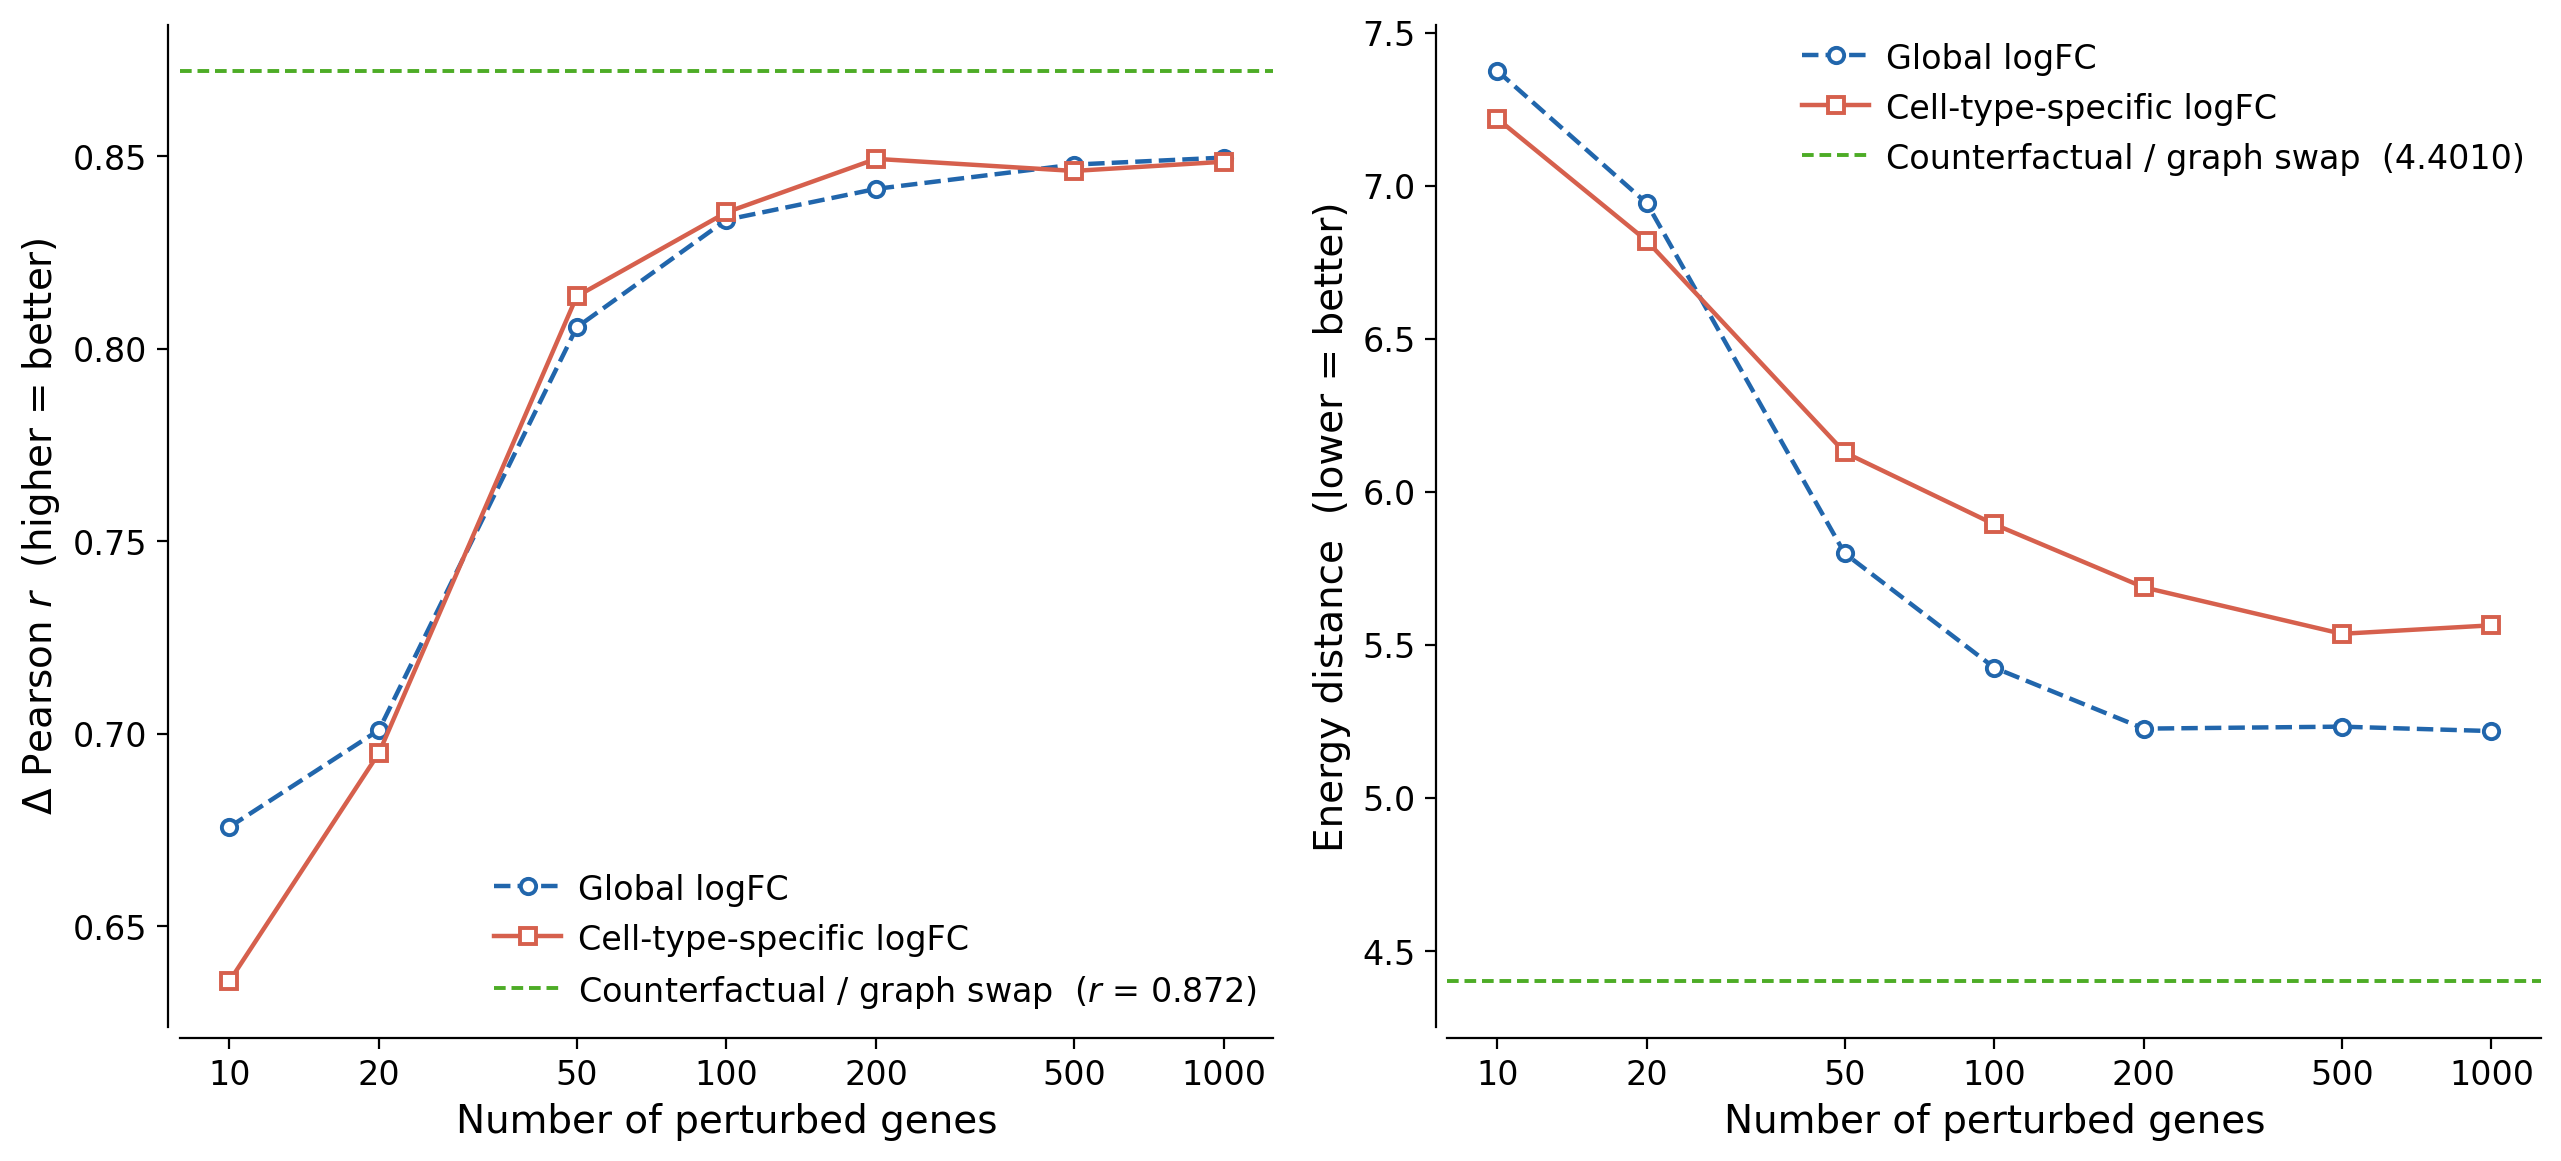

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Nature-style rcParams ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 200,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

# Nature palette — muted, print-friendly
BLUE   = '#2166AC'
ORANGE = '#D6604D'
GREEN  = '#4DAC26'

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Left panel: Pearson r ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(
    top_n_perturb_values, global_results,
    color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Global logFC',
    zorder=3,
)
ax.plot(
    top_n_perturb_values, ctspec_results,
    color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Cell-type-specific logFC',
    zorder=3,
)
ax.axhline(
    cf_avg_pearson,
    color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
    label=f'Counterfactual / graph swap  ($r$ = {cf_avg_pearson:.3f})',
    zorder=2,
)
ax.set_xscale('log')
ax.set_xticks(top_n_perturb_values)
ax.set_xticklabels([str(v) for v in top_n_perturb_values])
ax.xaxis.set_minor_locator(ticker.NullLocator())
ax.set_xlabel('Number of perturbed genes', fontsize=14)
ax.set_ylabel('Δ Pearson $r$  (higher = better)', fontsize=14)
ax.spines['left'].set_position(('outward', 4))
ax.spines['bottom'].set_position(('outward', 4))
ax.legend(frameon=False, handlelength=2.0)

# ── Right panel: Energy distance ──────────────────────────────────────────
ax2 = axes[1]
ax2.plot(
    top_n_perturb_values, global_edist_results,
    color=BLUE, ls='--', marker='o', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Global logFC',
    zorder=3,
)
ax2.plot(
    top_n_perturb_values, ctspec_edist_results,
    color=ORANGE, ls='-', marker='s', ms=5.5, lw=1.6,
    markerfacecolor='white', markeredgewidth=1.4,
    label='Cell-type-specific logFC',
    zorder=3,
)
ax2.axhline(
    cf_avg_edistance,
    color=GREEN, ls=(0, (3, 1.5)), lw=1.4,
    label=f'Counterfactual / graph swap  ({cf_avg_edistance:.4f})',
    zorder=2,
)
ax2.set_xscale('log')
ax2.set_xticks(top_n_perturb_values)
ax2.set_xticklabels([str(v) for v in top_n_perturb_values])
ax2.xaxis.set_minor_locator(ticker.NullLocator())
ax2.set_xlabel('Number of perturbed genes', fontsize=14)
ax2.set_ylabel('Energy distance  (lower = better)', fontsize=14)
ax2.spines['left'].set_position(('outward', 4))
ax2.spines['bottom'].set_position(('outward', 4))
ax2.legend(frameon=False, handlelength=2.0)

fig.tight_layout()
# plt.savefig(save_fig, bbox_inches='tight')
plt.show()
